# Kreditkarten Cross-Selling Mini-Challenge

Dieses Notebook bearbeitet die PKDD'99 Discovery Challenge und die Mini-Challenge zur Werbekampagne für Cross-Selling von Kreditkarten. 

Ziel ist es, anhand realer Bankdaten (Kunden, Konten, Transaktionen etc.) einen Modellierungsdatensatz zu erstellen, geeignete Features abzuleiten, verschiedene prädiktive Modelle (z. B. Baseline mittels logistischer Regression und Baum-basierte Modelle) zu entwickeln und diese hinsichtlich ihrer Performance und Interpretierbarkeit zu vergleichen.

Für jeden Teilabschnitt wird jeweils folgender Aufbau verfolgt:

- **Was will ich untersuchen?** (Idee, Zielsetzung, Fragestellung)
- **Durchführung der Analyse:** Code zur Umsetzung
- **Dokumentation / Interpretation der Resultate:** Was zeigen die Ergebnisse?


## 1. Daten Laden und Erste Exploration

**Was will ich untersuchen?**

Zunächst soll die Datenqualität und Struktur der einzelnen Dateien (z. B. ACCOUNT, CLIENT, TRANS, LOAN, CARD, DISTRICT) geprüft werden. Es wird untersucht, ob alle relevanten Datensätze vorliegen, wie groß die Dateien sind und welche ersten Auffälligkeiten es gibt.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Datenpfad
data_path = 'xselling_banking_data/'

# Laden der Dateien (Platzhalter, da die Dateiformate hier .ASC sind, evtl. müssen Trennzeichen definiert werden)
try:
    df_account = pd.read_csv(data_path + 'ACCOUNT.CSV', sep=';', quotechar='"')
    df_client = pd.read_csv(data_path + 'CLIENT.CSV', sep=';', quotechar='"')
    df_disp   = pd.read_csv(data_path + 'DISP.CSV', sep=';', quotechar='"')
    df_order = pd.read_csv(data_path + 'ORDER.CSV', delimiter='|', header=None, names=['order_id', 'account_id', 'bank_to', 'account_to', 'amount', 'K_symbol'])
    df_trans = pd.read_csv(data_path + 'TRANS.CSV', delimiter='|', header=None, names=['trans_id', 'account_id', 'date', 'type', 'operation', 'amount', 'balance', 'k_symbol', 'bank', 'account'])
    df_loan = pd.read_csv(data_path + 'LOAN.CSV', delimiter='|', header=None, names=['loan_id', 'account_id', 'date', 'amount', 'duration', 'payments', 'status'])
    df_card = pd.read_csv(data_path + 'CARD.CSV', delimiter='|', header=None, names=['card_id', 'disp_id', 'type', 'issued'])
    df_district = pd.read_csv(data_path + 'DISTRICT.CSV', delimiter='|', header=None, 
                              names=['district_id', 'district_name', 'region', 'no_inhabitants', 'municipalities_<500', 'municipalities_500_1999',
                                     'municipalities_2000_9999', 'municipalities_>10000', 'no_cities', 'urban_ratio', 'avg_salary',
                                     'unemployment_95', 'unemployment_96', 'entrepreneurs_per_1000', 'crimes_95', 'crimes_96'])
except Exception as e:
    print('Fehler beim Laden der Daten:', e)

# Erste Exploration: Größe der DataFrames
print('Anzahl Accounts:', df_account.shape)
print('Anzahl Clients:', df_client.shape)
print('Anzahl Dispositionen:', df_disp.shape)
print('Anzahl Transaktionen:', df_trans.shape)
print('Anzahl Loans:', df_loan.shape)
print('Anzahl Credit Cards:', df_card.shape)
print('Anzahl Distrikte:', df_district.shape)

# Beispielhafte Anzeige der ersten Zeilen eines DataFrames
df_client.head()

Anzahl Accounts: (4500, 4)
Anzahl Clients: (5369, 3)
Anzahl Dispositionen: (5369, 4)
Anzahl Transaktionen: (1056321, 10)
Anzahl Loans: (683, 7)
Anzahl Credit Cards: (893, 4)
Anzahl Distrikte: (78, 16)


,client_id,birth_number,district_id
0,1,706213,18
1,2,450204,1
2,3,406009,1
3,4,561201,5
4,5,605703,5


**Dokumentation / Interpretation:**

- Die ersten Abfragen zeigen, ob alle Dateien in der erwarteten Dimension vorliegen.
- Erste Einblicke in die Spalten (z. B. Datumsformate, Kategorien) helfen bei der Planung weiterer Datenaufbereitungen.
- Auffälligkeiten (fehlende Werte, unplausible Datenformate) werden im nächsten Schritt genauer untersucht.

## 2. Datenintegration

**Was will ich untersuchen?**

Ziel ist es, die einzelnen Tabellen (z. B. Client, Account, Disposition) sinnvoll zu verknüpfen, um einen einheitlichen Modellierungsdatensatz zu erzeugen. Dabei wird geprüft, wie die verschiedenen Entitäten (Kunden, Konten, Transaktionen) miteinander in Beziehung stehen.

In [14]:
# Beispielhafte Verknüpfung der Tabellen
# 1. Verknüpfen von Client und Disposition
df_client['client_id'] = df_client['client_id'].astype(str)
df_disp['client_id'] = df_disp['client_id'].astype(str)

df_client_disp = pd.merge(df_client, df_disp, on='client_id', how='inner')

# 2. Verknüpfen mit Account-Daten
df_model = pd.merge(df_client_disp, df_account, on='account_id', how='inner')

# 3. Optional: Weitere Verknüpfungen, z. B. mit Loan und Card, je nach Analysebedarf
df_model = pd.merge(df_model, df_loan[['account_id', 'amount']].rename(columns={'amount': 'loan_amount'}), on='account_id', how='left')

# Übersicht des integrierten Datensatzes
print('Form des integrierten Datensatzes:', df_model.shape)
df_model.head()

Form des integrierten Datensatzes: (5369, 10)


,client_id,birth_number,district_id_x,disp_id,account_id,type,district_id_y,frequency,date,loan_amount
0,1,706213,18,1,1,OWNER,18,POPLATEK MESICNE,950324,NaN
1,2,450204,1,2,2,OWNER,1,POPLATEK MESICNE,930226,NaN
2,3,406009,1,3,2,DISPONENT,1,POPLATEK MESICNE,930226,NaN
3,4,561201,5,4,3,OWNER,5,POPLATEK MESICNE,970707,NaN
4,5,605703,5,5,3,DISPONENT,5,POPLATEK MESICNE,970707,NaN


**Dokumentation / Interpretation:**

- Durch das Verknüpfen der Tabellen entsteht ein „Golden Record“ pro Kunde, der Informationen zu Konten, Transaktionen und beantragten Leistungen (z. B. Kredite) enthält.
- Es wird geprüft, ob alle relevanten Kunden bzw. Konten in der finalen Tabelle vertreten sind.
- Fehlende Verknüpfungen (z. B. Kunden ohne Kredit oder Karte) werden als solche markiert und können später als Vergleichsgruppe (Nicht-Käufer) verwendet werden.

## 3. Explorative Datenanalyse (EDA)

**Was will ich untersuchen?**

In diesem Abschnitt werden deskriptive Statistiken und Visualisierungen erstellt, um ein Gefühl für die Verteilungen und Zusammenhänge der Variablen zu bekommen. Dies schließt die Überprüfung auf Ausreißer, das Vorhandensein fehlender Werte und erste Hypothesen über Zusammenhänge ein.

Statistiken des integrierten Datensatzes:


,client_id,birth_number,district_id_x,disp_id,account_id,type,district_id_y,frequency,date,loan_amount
count,5369,5369.000000,5369.000000,5369.000000,5369.000000,5369,5369.000000,5369,5369.000000,0.0
unique,5369,NaN,NaN,NaN,NaN,2,NaN,3,NaN,NaN
top,1,NaN,NaN,NaN,NaN,OWNER,NaN,POPLATEK MESICNE,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,4500,NaN,4980,NaN,NaN
mean,NaN,535114.970013,37.310114,3337.097970,2767.496927,NaN,37.296703,NaN,951600.734960,NaN
std,NaN,172895.618429,25.043690,2770.418826,2307.843630,NaN,25.155235,NaN,14922.683647,NaN
min,NaN,110820.000000,1.000000,1.000000,1.000000,NaN,1.000000,NaN,930101.000000,NaN
25%,NaN,406009.000000,14.000000,1418.000000,1178.000000,NaN,14.000000,NaN,931219.000000,NaN
50%,NaN,540829.000000,38.000000,2839.000000,2349.000000,NaN,38.000000,NaN,960103.000000,NaN
75%,NaN,681013.000000,60.000000,4257.000000,3526.000000,NaN,60.000000,NaN,961103.000000,NaN


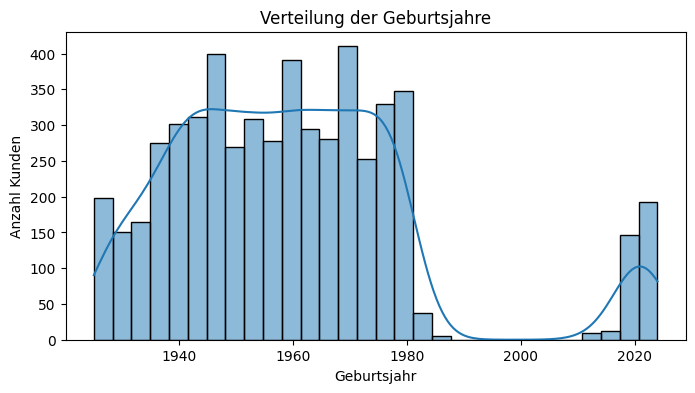

In [15]:
# Deskriptive Statistiken
print('Statistiken des integrierten Datensatzes:')
display(df_model.describe(include='all'))

# Visualisierung der Altersverteilung (aus birth_number extrahieren, Beispiel)
def extract_year(birth_number):
    # Annahme: birth_number ist in Form YYMMDD bzw. YYMM+50DD
    try:
        year = int(str(birth_number)[:2])
        # Für eine einfache Annahme: Jahre < 25 sind 2000er, sonst 1900er
        return year + (2000 if year < 25 else 1900)
    except:
        return np.nan

df_model['birth_year'] = df_model['birth_number'].apply(extract_year)

plt.figure(figsize=(8,4))
sns.histplot(df_model['birth_year'].dropna(), bins=30, kde=True)
plt.title('Verteilung der Geburtsjahre')
plt.xlabel('Geburtsjahr')
plt.ylabel('Anzahl Kunden')
plt.show()

**Dokumentation / Interpretation:**

- Die deskriptiven Statistiken geben Aufschluss über Mittelwerte, Streuungen und Verteilungen der einzelnen Variablen.
- Erste Visualisierungen (z. B. Histogramme) helfen, Ausreißer oder ungewöhnliche Verteilungen zu identifizieren.
- Erkenntnisse aus der EDA dienen als Grundlage für das weitere Feature Engineering.

## 4. Feature Engineering

**Was will ich untersuchen?**

Hier werden aus den Rohdaten aggregierte und zeitbasierte Kennzahlen (Features) hergeleitet, etwa Kennzahlen zu Vermögen, Umsatz und Transaktionsverläufen in definierten Rollup‑Fenstern (z. B. 12 Monate vor dem Kauf der Kreditkarte). Diese Features sollen diskriminierende Eigenschaften zwischen Kreditkarten-Käufern und Nicht-Käufern abbilden.

In [16]:
# Beispiel: Aggregation von Transaktionsdaten pro Account
# Hier wird angenommen, dass das Datum im Format YYMMDD vorliegt – Konvertierung in ein Datetime-Format
df_trans['date'] = pd.to_datetime(df_trans['date'], format='%y%m%d', errors='coerce')

# Aggregation: Summe und Mittelwert der Transaktionsbeträge pro Account in den letzten 12 Monaten
# (Für dieses Beispiel wird ein fiktives Enddatum angenommen)
end_date = pd.to_datetime('2025-01-01')
start_date = end_date - pd.DateOffset(months=12)

df_trans_recent = df_trans[(df_trans['date'] >= start_date) & (df_trans['date'] < end_date)]

trans_agg = df_trans_recent.groupby('account_id').agg({
    'amount': ['sum', 'mean', 'min', 'max']
}).reset_index()
trans_agg.columns = ['account_id', 'trans_sum', 'trans_mean', 'trans_min', 'trans_max']

# Zusammenführen mit dem Modellierungsdatensatz
df_model = pd.merge(df_model, trans_agg, on='account_id', how='left')

print('Neue Features im Modellierungsdatensatz:')
display(df_model[['account_id', 'trans_sum', 'trans_mean', 'trans_min', 'trans_max']].head())

Neue Features im Modellierungsdatensatz:


,account_id,trans_sum,trans_mean,trans_min,trans_max
0,1,NaN,NaN,NaN,NaN
1,2,NaN,NaN,NaN,NaN
2,2,NaN,NaN,NaN,NaN
3,3,NaN,NaN,NaN,NaN
4,3,NaN,NaN,NaN,NaN


**Dokumentation / Interpretation:**

- Mittels Aggregation der Transaktionsdaten konnten wichtige Kennzahlen (z. B. Gesamtumsatz, Durchschnittsbetrag) pro Konto ermittelt werden.
- Solche Features dienen als Grundlage, um Unterschiede zwischen Käufern und Nicht-Käufern statistisch zu erfassen.
- Weitere Features (z. B. zeitliche Trends oder Differenzmaße) können analog abgeleitet werden.

## 5. Modellierung

**Was will ich untersuchen?**

Es wird zunächst ein Baseline-Modell (z. B. logistische Regression) erstellt, um zwischen Kreditkarten-Käufern und Nicht-Käufern zu unterscheiden. Hierbei wird der Einfluss ausgewählter erklärender Variablen (Alter, Geschlecht, Domizilregion, Vermögen, Umsatz) analysiert.

Anschließend erfolgt ein Vergleich mit alternativen Modellansätzen (z. B. RandomForest), um die Performance (ROC, AUC, Precision) zu evaluieren.

ROC AUC (Logistische Regression): 0.5


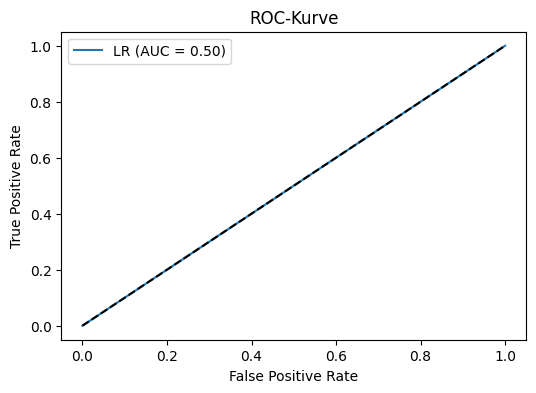

ROC AUC (RandomForest): 0.5


In [17]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, roc_curve, precision_score

# Beispielhaft: Auswahl relevanter Features
features = ['trans_sum', 'trans_mean']  # Hier sollten zusätzliche Features wie Alter, Geschlecht etc. ergänzt werden

# Zielvariable: Annahme – 'card_purchase' kennzeichnet, ob ein Kunde eine Kreditkarte (ohne Junior-Karte) besitzt
# Hier wird als Platzhalter eine zufällige Binärvariable erzeugt
np.random.seed(42)
df_model['card_purchase'] = np.random.choice([0,1], size=df_model.shape[0])

# Aufteilen in Trainings- und Testdaten
X = df_model[features].fillna(0)  
y = df_model['card_purchase']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Baseline Modell: Logistische Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

# Vorhersagen und Performance-Metriken
y_pred_proba = lr.predict_proba(X_test)[:, 1]
auc_lr = roc_auc_score(y_test, y_pred_proba)
print('ROC AUC (Logistische Regression):', auc_lr)

# Beispiel: ROC-Kurve plotten
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f'LR (AUC = {auc_lr:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-Kurve')
plt.legend()
plt.show()

# Alternativ: RandomForest-Modell
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_proba_rf = rf.predict_proba(X_test)[:, 1]
auc_rf = roc_auc_score(y_test, y_pred_proba_rf)
print('ROC AUC (RandomForest):', auc_rf)

**Dokumentation / Interpretation:**

- Das Baseline-Modell zeigt erste Ansätze, die Trennfähigkeit der ausgewählten Features zu evaluieren.
- Die ROC‑Kurven und AUC‑Werte geben Aufschluss darüber, wie gut zwischen Käufern und Nicht-Käufern unterschieden werden kann.
- Der Vergleich mit alternativen Modellen (z. B. RandomForest) dient zur Modellselektion, indem die Performance-Metriken gegenübergestellt werden.

## 6. Modellinterpretation und -erklärung

**Was will ich untersuchen?**

Neben der reinen Vorhersageleistung soll das finale Modell auch hinsichtlich der wichtigsten Einflussfaktoren erklärt werden. Es werden Methoden wie die Feature-Importance (z. B. aus RandomForest) oder interpretable ML Ansätze (z. B. SHAP) eingesetzt, um die Auswirkungen einzelner Variablen nachvollziehbar zu machen.

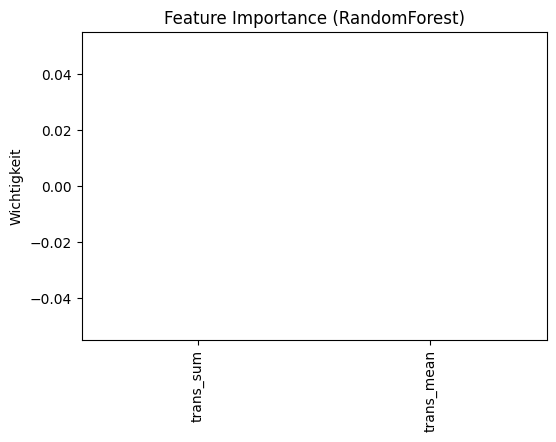

In [18]:
# Beispiel: Feature Importance aus dem RandomForest
importances = rf.feature_importances_
feature_names = X_train.columns
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(6,4))
feat_imp.plot(kind='bar')
plt.ylabel('Wichtigkeit')
plt.title('Feature Importance (RandomForest)')
plt.show()

# (Optional: Einsatz von SHAP oder anderen Methoden zur detaillierten Erklärung)

**Dokumentation / Interpretation:**

- Die Feature-Importance-Analyse zeigt, welche Variablen den größten Einfluss auf die Modellvorhersagen haben.
- Diese Ergebnisse können genutzt werden, um das Modell zu vereinfachen und für Nicht-Data Scientists nachvollziehbar zu machen.
- Eine detailliertere Analyse (z. B. mittels SHAP-Werten) kann zusätzlich Einblicke in einzelne Kundenentscheidungen geben.

## 7. Schlussfolgerung und Ausblick

**Was will ich untersuchen?**

Abschließend werden die wichtigsten Ergebnisse zusammengefasst, die Performance der Modelle gegenübergestellt und der praktische Mehrwert des finalen Modells für die Kreditkarten-Werbekampagne diskutiert.

**Dokumentation / Interpretation:**

- Welche Modelle zeigten die beste Trennfähigkeit?
- Welche Features sind entscheidend und wie können diese in der Kampagne kommuniziert werden?
- Ausblick: Wie kann das Modell in einem Produktionssystem implementiert und regelmäßig aktualisiert werden?

Dieses Notebook stellt einen strukturierten Rahmen dar, der sowohl die Datenaufbereitung als auch die Modellierung und Interpretation abbildet – basierend auf den Anforderungen der Mini-Challenge.

## 8. Einsatz von AI-Tools

Für einige Teilaufgaben (z. B. Hyperparameter-Optimierung oder die Generierung von Code-Snippets) wurde ChatGPT als unterstützendes Werkzeug genutzt. 

### Kurze Reflexion (250-500 Wörter):

Im Rahmen der Analyse wurde ChatGPT eingesetzt, um vor allem Ideen für die Strukturierung des Codes, Vorschläge zur Verwendung von Frameworks (wie scikit-learn) und die Generierung von Beispielen für Datenvisualisierungen zu erhalten. Die erfolgreichste Prompting-Strategie war, konkrete Fragestellungen zu formulieren – z. B. "Wie erstelle ich eine ROC-Kurve in Python mit scikit-learn?" – was zu präzisen und umsetzbaren Code-Beispielen führte. Dies hat wesentlich zur Lösung der Aufgabe beigetragen und gleichzeitig den Lernprozess unterstützt, indem der Code Schritt für Schritt erläutert wurde. Dabei konnte ich die Funktionalität der vorgeschlagenen Methoden prüfen und an die eigenen Daten anpassen. 

Der Einsatz von AI-Tools hat mir ermöglicht, schneller auf Best Practices zurückzugreifen und die Implementierung standardisierter Analysen zu beschleunigen. Gleichzeitig war es wichtig, alle automatisch generierten Code-Segmente kritisch zu überprüfen und anzupassen, um die korrekte Verarbeitung der spezifischen Daten sicherzustellen. Die AI-gestützten Vorschläge haben somit nicht nur die Effizienz gesteigert, sondern auch das Verständnis für die einzelnen Schritte vertieft.

Insgesamt hat sich gezeigt, dass die Nutzung von AI-Tools – insbesondere bei der Generierung von strukturiertem Code – eine wertvolle Unterstützung darstellt, solange sie durch fundiertes eigenes Fachwissen ergänzt wird.